In [1]:
# Import required plotting and data analysis libraries
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [3]:
# Load your dataset (adjust path if needed)
data = pd.read_csv(r"C:\Users\guddi\OneDrive\文档\GOURI\Data Analyst course\Minor project\Mobiles Dataset (2025).csv", encoding="latin-1")


In [9]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Load the dataset
data =pd.read_csv(r"C:\Users\guddi\OneDrive\文档\GOURI\Data Analyst course\Minor project\Mobiles Dataset (2025).csv", encoding="latin-1")


# Clean up the 'Launched Price (India)' column so it's numeric
import re
def clean_price(x):
    if pd.isna(x): 
        return None
    x = str(x)
    x = re.sub(r'[^0-9.]', '', x)
    try:
        return float(x)
    except:
        return None

data['Launched Price (India)'] = data['Launched Price (India)'].apply(clean_price)

# Rename it for easier reference
data.rename(columns={'Launched Price (India)': 'Price_INR'}, inplace=True)


In [11]:
brand_price_inr = (
    data.groupby('Company Name')['Price_INR']
    .agg(['count', 'mean', 'median'])
    .reset_index()
    .sort_values('mean', ascending=False)
)
print(brand_price_inr.head())


   Company Name  count           mean   median
0         Apple     97  102998.597938  99999.0
3        Huawei     42  102798.571429  84999.0
14         Sony      9   91665.666667  94999.0
1        Google     21   70332.333333  59999.0
13      Samsung     88   63605.500000  64999.0


In [13]:
out_dir = Path("charts")
out_dir.mkdir(exist_ok=True)


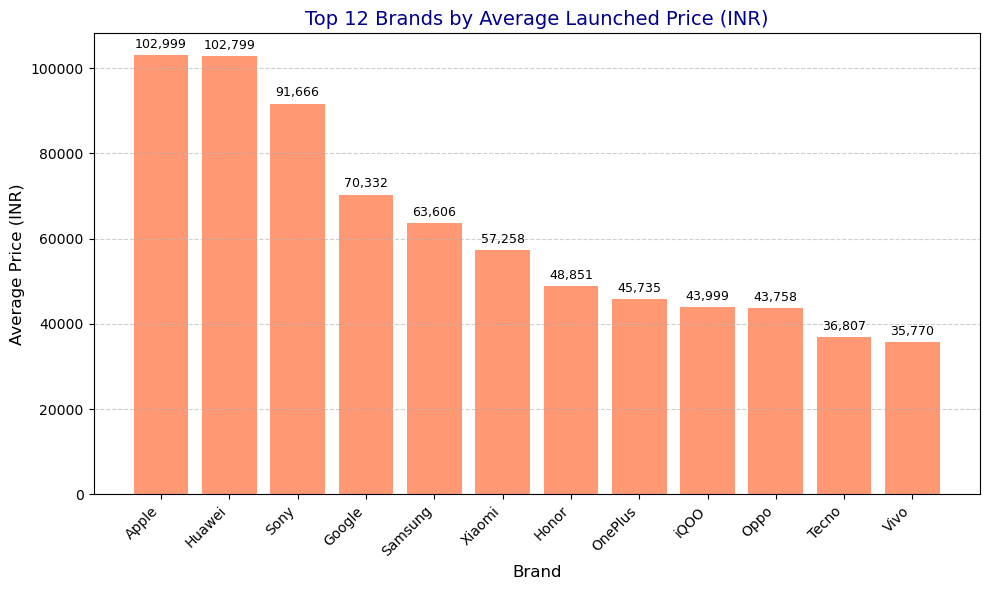

In [15]:
plt.figure(figsize=(10,6))
bp = brand_price_inr.head(12)
plt.bar(bp['Company Name'], bp['mean'], color='coral', alpha=0.8)
plt.xticks(rotation=45, ha='right')
plt.title('Top 12 Brands by Average Launched Price (INR)', fontsize=14, color='darkblue')
plt.xlabel('Brand', fontsize=12)
plt.ylabel('Average Price (INR)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Add labels above bars
for idx, val in enumerate(bp['mean']):
    plt.text(idx, val + 1000, f"{val:,.0f}", ha='center', va='bottom', fontsize=9, color='black')

plt.tight_layout()
plt.savefig(out_dir / "avg_price_by_brand_inr.png")
plt.show()
